In [9]:
from langchain_classic.chains.question_answering.map_reduce_prompt import messages
from langchain_openai import OpenAIEmbeddings
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.vectorstores import InMemoryVectorStore
import bs4
from langmem.graphs.semantic import graph

from demo import result1

In [16]:
ZHIPU_API_KEY = "ad5c47ea564a4f618268919f127bb33a.EJmr2BQ23o6P2dg8"
ZHIPU_BASE_URL = "https://open.bigmodel.cn/api/paas/v4/"

zhipu_embeddings = OpenAIEmbeddings(
    model="embedding-3",
    openai_api_key=ZHIPU_API_KEY,
    openai_api_base=ZHIPU_BASE_URL,
)

In [7]:
# 加载网页
loader = WebBaseLoader(
  web_path=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
  bs_kwargs={
    "parse_only": bs4.SoupStrainer(
      class_=('post-title', 'post-header', 'post-content')
    )
  }
)

docs = loader.load()
docs

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='\n\n      LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng\n\n\nBuilding agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview#\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistake

In [10]:
text_splits = RecursiveCharacterTextSplitter(
  chunk_size=1000,
  chunk_overlap=200
)

all_splits = text_splits.split_documents(docs)

all_splits

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng\n\n\nBuilding agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview#\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refi

In [17]:
# 向量化 + 存储
vector_store = InMemoryVectorStore(zhipu_embeddings)
vector_store.add_documents(all_splits)

vector_store

In [23]:
from langchain.tools import tool

In [24]:
@tool(response_format='content_and_artifact')
def retrieve(query: str):
  """search blog posts for relevant information to answer user questions"""
  retrieved_docs = vector_store.similarity_search(query, k=5)
  serialized = "\n\n".join(
        f"Source: {doc.metadata}\nContent: {doc.page_content}"
        for doc in retrieved_docs
    )
  return serialized, retrieved_docs

搭建图节点

LangGraph 的核心概念是 StateGraph——用图来编排流程，节点是操作，边是流转逻辑。状态用 `MessagesState`，本质上就是一个消息列表，所有节点共享。

In [25]:
from langchain_core.messages import SystemMessage
from langgraph.graph import MessagesState
from config.llm import llm

/home/jiangtong/桌面/agent/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3701: UserWarning: WARNING! openai_api_key is not default parameter.
                openai_api_key was transferred to model_kwargs.
                Please confirm that openai_api_key is what you intended.
  exec(code_obj, self.user_global_ns, self.user_ns)
/home/jiangtong/桌面/agent/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3701: UserWarning: WARNING! openai_api_base is not default parameter.
                openai_api_base was transferred to model_kwargs.
                Please confirm that openai_api_base is what you intended.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [26]:
def generate_query_or_respond(state: MessagesState):
  """Agent 决策：搜索还是直接回答"""
  llm_with_tools = llm.bind_tools([retrieve])
  
  system = SystemMessage(
        content="你是一个博客文章问答助手。当用户的问题涉及 AI Agent、LLM、任务分解、"
                "记忆机制等技术话题时，你必须先使用 retrieve 工具搜索文档来获取准确信息。"
                "只有当问题明显与技术无关（如闲聊、简单数学）时，才直接回答。"
                "重要：知识库中的文档是英文的，所以你在调用 retrieve 工具时，query 参数必须用英文。"
    )
  response = llm_with_tools.invoke([system] + state['messages'])
  return {
    "messages": [response]
  }

##### 检索
当 Agent 决定要搜索时，这个节点负责执行实际的检索。用 LangGraph 内置的 ToolNode，一行搞定：

In [27]:
from langgraph.prebuilt import ToolNode

retrieve_node = ToolNode([retrieve])

# ToolNode 会自动读取上一步 Agent 生成的 tool call，调用对应的工具，把结果包装成 ToolMessage 塞回状态里。

文档评估

In [28]:
def grade_documents(state: MessagesState):
  """评估检索文档的相关性"""
  messages = state['messages']
  
#   拿到用户原始问题和检索结果
  question = messages[0].content
  tool_content = ""
  
  for msg in reversed(messages):
    if hasattr(msg, "type") and msg.type == "tool":
      tool_content = msg.content
      break
     
    grading_prompt = (
      "你是一个评估检索文档与用户问题相关性的评分员。\n"
        "如果文档包含与问题相关的关键词或语义内容，回复 yes。\n"
        "如果文档与问题完全无关，回复 no。\n"
        "只回复 yes 或 no，不要解释。\n\n"
        f"用户问题：{question}\n\n"
        f"检索到的文档：{tool_content[:2000]}"
    ) 
    
    response = llm.invoke([("human", grading_prompt)])
    score = response.content.strip().lower()

    if "yes" in score:
        print("--- 评估结果：文档相关 ---")
        return {"messages": state["messages"]}
    else:
        print("--- 评估结果：文档不相关 ---")
        return {"messages": [messages[0]]}

问题改写

In [29]:
def rewrite_question(state: MessagesState):
  """改写问题以优化检索效果。"""
  question = state['messages'][0].content
  msg = llm.invoke(
    [SystemMessage(content='优化下面的问题，使其更适合语义搜索，只输出改写后的问题，不要解释')]
    + [("human", question)],
  )
  print(f"--- 问题改写：{question} → {msg.content} ---")
  return {"messages": [("human", msg.content)]}

生成回答

In [30]:
def generate_answer(state: MessagesState):
  """基于检索到的文档生成回答。"""
  messages = state['messages']
  
  doc_content = ""
  
  for msg in reversed(messages):
    if hasattr(msg, "type") and msg.type == "tool":
      docs_content = msg.content
      break
      
  question = messages[0].content
  response = llm.invoke([SystemMessage(content="你是一个问答助手。根据检索到的文档回答问题。用中文回答，简洁准确。")]
        + [("human", f"问题：{question}\n\n参考文档：\n{docs_content}")])
  
  return {"messages": [response]}

把节点连成图

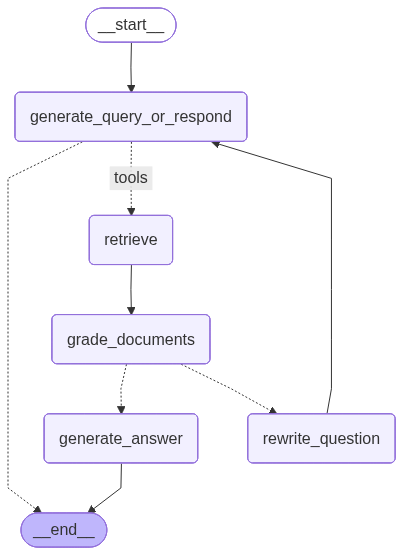

In [36]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import tools_condition

graph_builder = StateGraph(MessagesState)

# 加节点
graph_builder.add_node("generate_query_or_respond", generate_query_or_respond)
graph_builder.add_node("retrieve", retrieve_node)
graph_builder.add_node("grade_documents", grade_documents)
graph_builder.add_node("rewrite_question", rewrite_question)
graph_builder.add_node("generate_answer", generate_answer)

# 入口 → Agent 决策
graph_builder.add_edge(START, "generate_query_or_respond")

# Agent 决策后的条件路由
# 有 tool_call → 去检索；没有 → 直接结束
graph_builder.add_conditional_edges(
    "generate_query_or_respond",
    tools_condition,
    {"tools": "retrieve", END: END},
)

# 检索完 → 评估文档
graph_builder.add_edge("retrieve", "grade_documents")

# 评估后的条件路由
def route_after_grading(state: MessagesState):
    if len(state["messages"]) == 1:
        return "rewrite_question"
    return "generate_answer"

graph_builder.add_conditional_edges(
    "grade_documents",
    route_after_grading,
    {"rewrite_question": "rewrite_question", "generate_answer": "generate_answer"},
)

# 改写问题 → 回到 Agent 决策（重新来一轮）
graph_builder.add_edge("rewrite_question", "generate_query_or_respond")

# 生成回答 → 结束
graph_builder.add_edge("generate_answer", END)

graph = graph_builder.compile()

graph

In [35]:
response = graph.invoke(
    {"messages": [("human", "Agent 有哪些类型的记忆？")]}
)
for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Agent 有哪些类型的记忆？
================================== Ai Message ==================================
Tool Calls:
  retrieve (call_-7833874009778289950)
 Call ID: call_-7833874009778289950
  Args:
    query: Agent memory types
================================= Tool Message =================================
Name: retrieve

Source: {'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}
Content: pytest
dataclasses

Source: {'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}
Content: Comparison of AD, ED, source policy and RL^2 on environments that require memory and exploration. Only binary reward is assigned. The source policies are trained with A3C for "dark" environments and DQN for watermaze.(Image source: Laskin et al. 2023)

Component Two: Memory#
(Big thank you to ChatGPT for helping me draft this section. I’ve learned a lot about the human brain and data structure for fast MIPS 

In [42]:
response = graph.invoke(
    {"messages": [("human", "你好，1+1等于几？")]}
)

for msg in response["messages"]:
    print('%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%') 
    msg.pretty_print()
    print('&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&') 
    print(msg)
    print('%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%') 


%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
================================ Human Message =================================

你好，1+1等于几？
&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&
content='你好，1+1等于几？' additional_kwargs={} response_metadata={} id='8d92e2e2-172f-44fe-9b3e-02b52ae80e5d'
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
================================== Ai Message ==================================

你好！1+1等于2。

这是一个简单的数学运算问题。如果你有关于AI Agent、LLM、任务分解、记忆机制等技术话题的问题，我可以帮你搜索相关的博客文章来回答。
&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&
content='你好！1+1等于2。\n\n这是一个简单的数学运算问题。如果你有关于AI Agent、LLM、任务分解、记忆机制等技术话题的问题，我可以帮你搜索相关的博客文章来回答。' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 103, 'prompt_tokens': 250, 'total_tokens': 353, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'glm-5', 'system_fingerprint': '', 'id': '', 'finish_reason': None, 'logprobs': None} id='lc_run--019cbcaf-e3d1-7672-82a0-2f

In [43]:
response = graph.invoke(
    {"messages": [("human", "什么是 Chain of Thought prompting？它和 Tree of Thoughts 有什么区别？")]}
)

for msg in response["messages"]:
    print(msg)
    msg.pretty_print()

response

content='什么是 Chain of Thought prompting？它和 Tree of Thoughts 有什么区别？' additional_kwargs={} response_metadata={} id='b51fcf60-5fa1-48be-acf1-9a363ac94124'
================================ Human Message =================================

什么是 Chain of Thought prompting？它和 Tree of Thoughts 有什么区别？
content='我来帮你搜索关于 Chain of Thought prompting 和 Tree of Thoughts 的相关信息。' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 121, 'prompt_tokens': 257, 'total_tokens': 378, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'glm-5', 'system_fingerprint': '', 'id': '', 'finish_reason': None, 'logprobs': None} id='lc_run--019cbde6-4c02-7063-a5ec-658e9f44982f-0' tool_calls=[{'name': 'retrieve', 'args': {'query': 'Chain of Thought prompting'}, 'id': 'call_-7833833911963613675', 'type': 'tool_call'}, {'name': 'retrieve', 'args': {'query': 'Tree of Thoughts'}, 'id': 'call_-7833833911963613674', 'type': 'tool_c

{'messages': [HumanMessage(content='什么是 Chain of Thought prompting？它和 Tree of Thoughts 有什么区别？', additional_kwargs={}, response_metadata={}, id='b51fcf60-5fa1-48be-acf1-9a363ac94124'),
  AIMessage(content='我来帮你搜索关于 Chain of Thought prompting 和 Tree of Thoughts 的相关信息。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 121, 'prompt_tokens': 257, 'total_tokens': 378, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'glm-5', 'system_fingerprint': '', 'id': '', 'finish_reason': None, 'logprobs': None}, id='lc_run--019cbde6-4c02-7063-a5ec-658e9f44982f-0', tool_calls=[{'name': 'retrieve', 'args': {'query': 'Chain of Thought prompting'}, 'id': 'call_-7833833911963613675', 'type': 'tool_call'}, {'name': 'retrieve', 'args': {'query': 'Tree of Thoughts'}, 'id': 'call_-7833833911963613674', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 257, 'output_tokens': 121, 't